## Imports

In [5]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

%load_ext autoreload
%autoreload all
from src.utils.eda_utils import (
    plot_target_distribution,
    plot_numerical_hist,
    plot_numerical_vs_target,
    analyze_categorical_feature,
    plot_categorical_distribution,
    analyze_neighborhoods
)

COLOR_FONT = 'dimgray'
COLOR_PLOT = 'tan'

plt.style.use('../styles/presentation.mplstyle')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data loading and initial overview

In [6]:
data = pd.read_csv('../data/processed/apartments_cleaned.csv')

In [7]:
print(f"Number of records: {len(data):,}")
print(f"Number of columns: {data.shape[1]}")

Number of records: 11,436
Number of columns: 28


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11436 entries, 0 to 11435
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   11436 non-null  int64  
 1   price                11436 non-null  int64  
 2   address              11436 non-null  object 
 3   coordinates          11307 non-null  object 
 4   region               11436 non-null  object 
 5   subway               9249 non-null   object 
 6   rooms                11436 non-null  int64  
 7   footage              11436 non-null  object 
 8   floor                11436 non-null  int64  
 9   features             11436 non-null  object 
 10  residential          5502 non-null   object 
 11  neighborhood         11436 non-null  object 
 12  description          11436 non-null  object 
 13  detail               11435 non-null  object 
 14  attributes           6865 non-null   object 
 15  full_area            11436 non-null 

In [9]:
print("Data types:")
data.dtypes.value_counts()

Data types:


object     17
int64       6
float64     5
Name: count, dtype: int64

In [10]:
missing = data.isna().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

In [11]:
print("Missing values:")
display(missing_df[missing_df['Missing Count'] > 0])

Missing values:


,Missing Count,Percentage
neighborhood_5,10987,96.073802
neighborhood_4,10102,88.335082
neighborhood_3,7393,64.646730
residential,5934,51.888772
attributes,4571,39.970269
neighborhood_2,4194,36.673662
subway,2187,19.123820
neighborhood_1,1088,9.513816
coordinates,129,1.128017
lat,129,1.128017


In [12]:
data.describe().round(2)

,id,price,rooms,floor,full_area,living_area,kitchen_area,num_storeys,lon,lat,unknown_living_area
count,11436.00,11436.00,11436.00,11436.00,11436.00,11432.0,11429.00,11436.00,11307.00,11307.00,11436.00
mean,11352935.53,1099.80,2.04,9.67,73.46,40.6,15.57,17.06,30.52,50.44,0.01
std,197542.54,11358.21,0.99,6.63,76.34,29.3,8.99,8.34,0.07,0.04,0.10
min,5030672.00,50.00,1.00,1.00,15.00,7.0,2.00,1.00,30.28,50.30,0.00
25%,11346713.25,380.00,1.00,4.00,45.00,20.0,10.00,9.00,30.48,50.41,0.00
50%,11400979.00,620.00,2.00,8.00,58.00,32.0,14.00,17.00,30.52,50.44,0.00
75%,11422115.50,1100.00,3.00,14.00,86.00,50.0,20.00,25.00,30.55,50.46,0.00
max,11448777.00,1150000.00,6.00,36.00,6635.00,500.0,140.00,47.00,30.74,50.57,1.00


## Target variable analysis

Our target is `price`

In [13]:
data['price'].describe(percentiles=[
    0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999
]).astype(int)

count      11436
mean        1099
std        11358
min           50
25%          380
50%          620
75%         1100
90%         1800
95%         2500
99%         4800
99.9%      15000
max      1150000
Name: price, dtype: int32

In [14]:
data['price'].sort_values(ascending=False)[:10]

5523     1150000
4240      195000
11293     165000
9050      158000
4204      145000
9541      139200
9540       93500
8506       64800
1837       55500
5948       19000
Name: price, dtype: int64

We see one clear outlier:
- The top value 1,150,000 is drastically higher than all others.
- The second-highest value is 195,000, which is almost 6 times lower.
This confirms that 1,150,000 is a true outlier.

In [15]:
print("With outlier:")
print(f"Mode: ${data['price'].mode()[0]}")
print(f"IQR: ${data['price'].quantile(0.75) - data['price'].quantile(0.25):,.0f}")
print(f"Coefficient of Variation: {data['price'].std() / data['price'].mean():.2f}")
print(f"Skewness: {data['price'].skew():.2f}")
print(f"Kurtosis: {data['price'].kurtosis():.2f}")

With outlier:
Mode: $370
IQR: $720
Coefficient of Variation: 10.33
Skewness: 91.86
Kurtosis: 9175.79


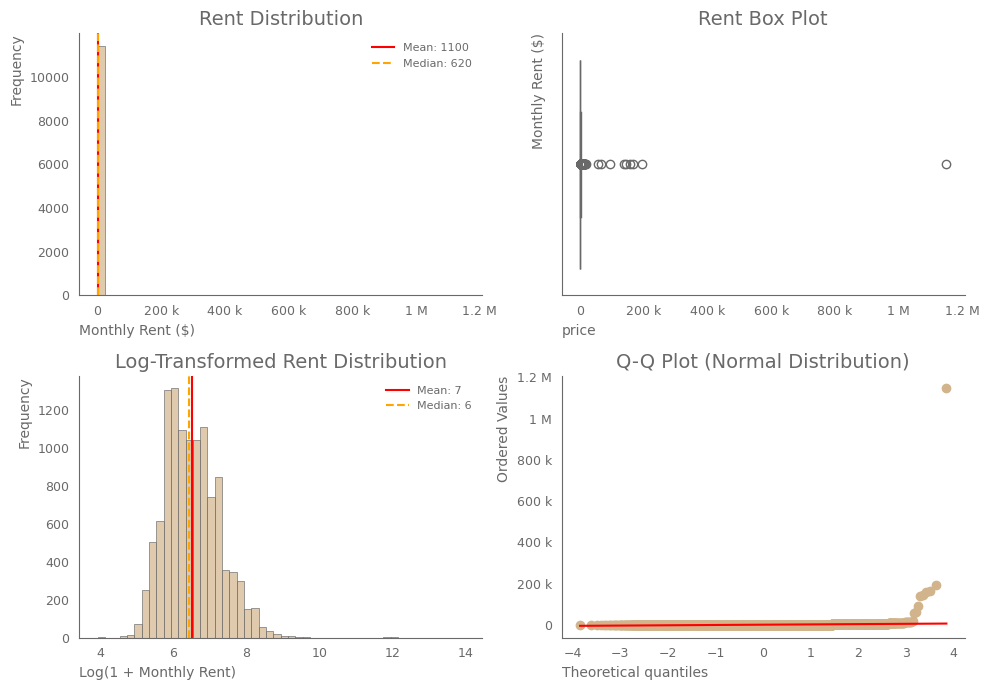

In [16]:
plot_target_distribution(data)

- Mode: $370 — the most frequent rental price remains very low.
- IQR: $720 — typical range is narrow, showing most prices are quite low.
- Coefficient of Variation: 10.33 — very high relative variability.
- Skewness: 91.86
- Kurtosis: 9175.79

**Conclusion:** The extreme outlier has a massive impact on dispersion and shape — the distribution is highly skewed and heavy-tailed, masking the behavior of most data points.

In [17]:
filtered_data = data[data['price'] < 1_000_000]

In [18]:
print("Without  outlier:")
print(f"Mode: ${filtered_data['price'].mode()[0]}")
print(f"IQR: ${filtered_data['price'].quantile(0.75) - filtered_data['price'].quantile(0.25):,.0f}")
print(f"Coefficient of Variation: {filtered_data['price'].std() / filtered_data['price'].mean():.2f}")
print(f"Skewness: {filtered_data['price'].skew():.2f}")
print(f"Kurtosis: {filtered_data['price'].kurtosis():.2f}")

Without  outlier:
Mode: $370
IQR: $720
Coefficient of Variation: 3.69
Skewness: 39.33
Kurtosis: 1727.98


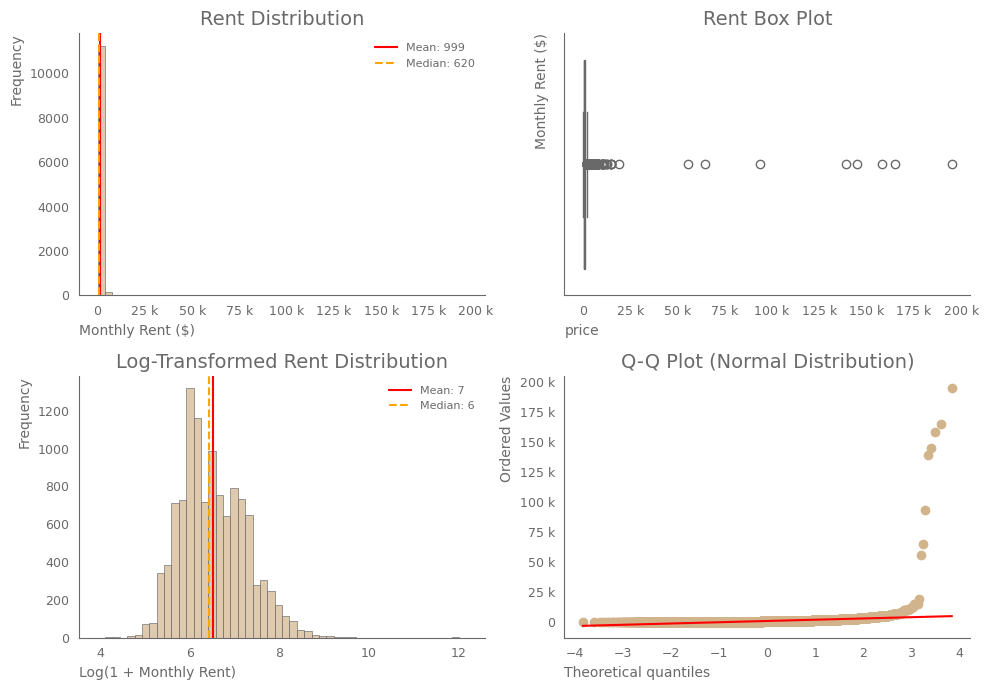

In [19]:
plot_target_distribution(filtered_data)

Without Top Outlier (1.15M Removed)
- Mode: Still $370 — the bulk of the data remains unchanged.
- IQR: Still $720 — central range unaffected.
- Coefficient of Variation: 3.69 — improved but still high.
- Skewness: 39.33
- Kurtosis: 1727.98

**Conclusions:**
- Removing the top outlier improves the distribution slightly, but it's still heavily right-skewed with extreme outliers present.
- This is common in real estate markets, where luxury or rare properties can distort the price distribution.

**Implications for Modeling:**
- Single top outlier (1.15M) dominates statistical moments. Removing just one outlier is not enough — there are 8 more large outliers (>$50K) that distort the distribution and affect model assumptions.
- These are likely additional extreme cases worth further inspection or filtering. Maybe treat it separately if we want to model luxury segments.
- Log transformation is likely necessary to normalize the distribution.
- Robust models (e.g., tree-based methods like Random Forest or Gradient Boosting) might perform better, as they are less sensitive to non-normality and outliers.
- Outlier handling may be useful during preprocessing, especially for linear models.

## Price ranges analysis

In [20]:
data['price_range'] = pd.cut(data['price'],
                             bins=[0, 500, 1000, 1500, 2000, 2500, 3000, float('inf')],
                             labels=['<$0.5K', '$0.5K-1K', '$1K-1.5K',
                                     '$1.5K-2K', '$2K-2.5K', '$2.5K-3K', '>$3K'])
price_dist = data['price_range'].value_counts().sort_index()
price_pct = (price_dist / len(data) * 100).round(1)

price_summary = pd.DataFrame({
    'Count': price_dist,
    'Percentage': price_pct
})

In [21]:
price_summary

,Count,Percentage
price_range,,
<$0.5K,4775,41.8
$0.5K-1K,3610,31.6
$1K-1.5K,1595,13.9
$1.5K-2K,611,5.3
$2K-2.5K,310,2.7
$2.5K-3K,192,1.7
>$3K,343,3.0


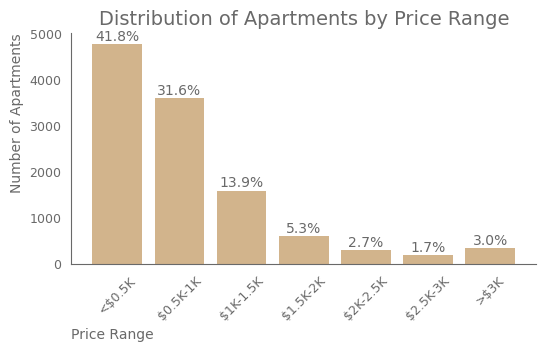

In [22]:
plt.figure(figsize=(6, 3))
bars = plt.bar(price_summary.index, price_summary['Count'], color=COLOR_PLOT)
plt.title('Distribution of Apartments by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Number of Apartments')
plt.xticks(rotation=45)

for bar, pct in zip(bars, price_summary['Percentage']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{pct}%", ha='center', va='bottom')

plt.show()

- Over 73% of all listings are priced below $1,000, with nearly 42% under $500.
- This confirms the extreme left clustering seen in histograms — the market is heavily skewed toward affordable rentals.
- Only 13.9% of listings are between $1K–$1.5K, and the share keeps shrinking as the price increases.
- Rentals above $2K account for just 7.4% of the dataset — highlighting their outlier status.
- The >$3K segment represents only 3%, yet it may heavily influence model behavior if not treated carefully due to their high absolute prices.

**Conclusions:**
- Using log(price) as a target may stabilizing variance across all ranges.
- If our model is expected to perform well across all price bands, consider:
    - Stratified evaluation by price range.
    - Separate modeling for luxury segment if behavior/features differ.

## Numerical features analysis

In [23]:
black_list = ['id', 'price']
numerical_cols = data.select_dtypes(include='number').columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in black_list]
print(f'Number of numerical features: {len(numerical_cols)}')
print(f"Numerical features: {numerical_cols}")

Number of numerical features: 9
Numerical features: ['rooms', 'floor', 'full_area', 'living_area', 'kitchen_area', 'num_storeys', 'lon', 'lat', 'unknown_living_area']


In [24]:
data[numerical_cols].describe().round(2)

,rooms,floor,full_area,living_area,kitchen_area,num_storeys,lon,lat,unknown_living_area
count,11436.00,11436.00,11436.00,11432.0,11429.00,11436.00,11307.00,11307.00,11436.00
mean,2.04,9.67,73.46,40.6,15.57,17.06,30.52,50.44,0.01
std,0.99,6.63,76.34,29.3,8.99,8.34,0.07,0.04,0.10
min,1.00,1.00,15.00,7.0,2.00,1.00,30.28,50.30,0.00
25%,1.00,4.00,45.00,20.0,10.00,9.00,30.48,50.41,0.00
50%,2.00,8.00,58.00,32.0,14.00,17.00,30.52,50.44,0.00
75%,3.00,14.00,86.00,50.0,20.00,25.00,30.55,50.46,0.00
max,6.00,36.00,6635.00,500.0,140.00,47.00,30.74,50.57,1.00


In [25]:
correlations = (data[numerical_cols + ['price']]
                .corr()['price']
                .sort_values(ascending=False))
print("Correlation with Target")
print(correlations.drop('price').round(3))

Correlation with Target
living_area            0.084
rooms                  0.072
full_area              0.052
kitchen_area           0.049
floor                  0.009
num_storeys            0.005
lon                    0.001
unknown_living_area   -0.004
lat                   -0.010
Name: price, dtype: float64


- There are only weak correlation with target
    - `living_area`: 0.084
    - `rooms`: 0.072
    - Others close to 0 or even negative (e.g. lat)

- This suggests either the target (rent) is influenced by non-numeric factors or there are nonlinear or interaction effects.
- Features like `full_area`, `living_area`, and `kitchen_area` have extreme outliers that hide general trends, so we could use IQR filtering for visualization.

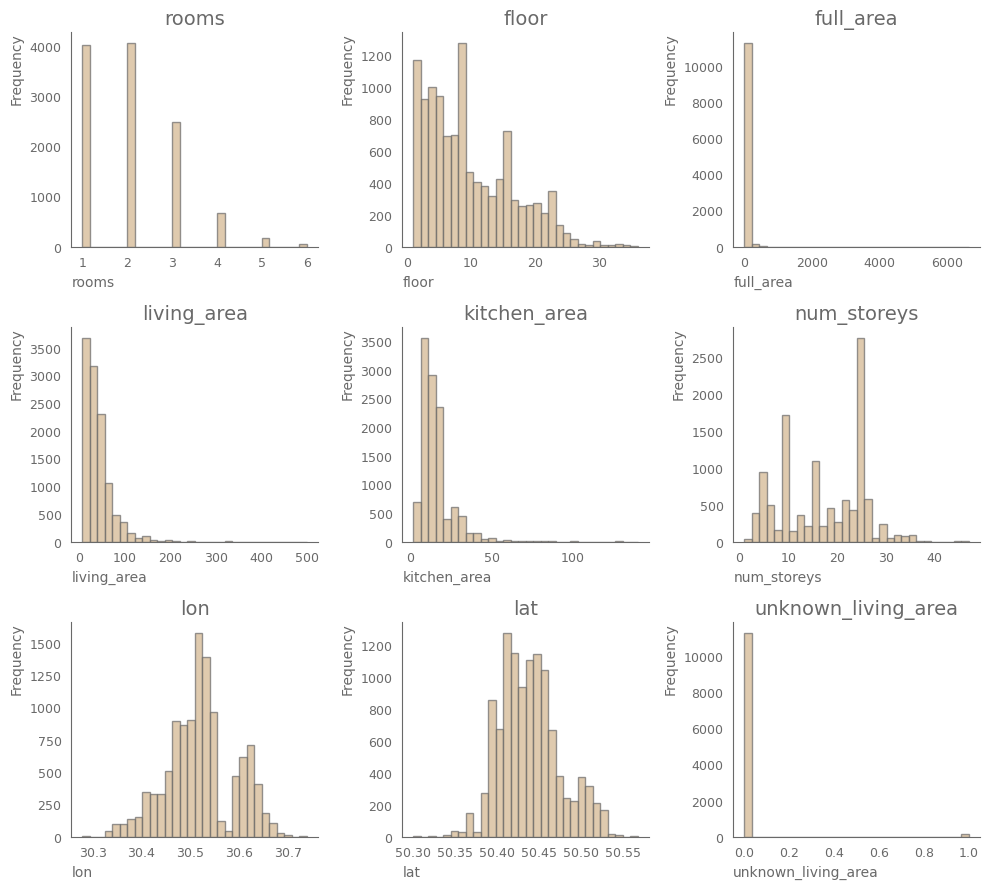

In [26]:
plot_numerical_hist(data, numerical_cols, n_cols=3)

- `rooms`: Most common values are 1–3 rooms, peaking at 1 and 2. Very few listings with 4, 5, or 6 rooms → treat higher values as rare cases. Consider grouping 4+ rooms in categorical plots or treating as long tail.
- `floor`: Generally decreasing, but notable peaks at floor 10 and 16. This could reflect architectural patterns (e.g., panel buildings) or buyer preferences. Could consider binning (e.g., low-rise, mid-rise, high-rise).
- `full_area`: All values are concentrated in one bin, likely due to extreme outliers dominating the scale. Histogram becomes unreadable. Requires log scale or IQR filtering for meaningful visualization.
- `living_area`: Most listings have areas between 0–100, with a sharp drop after that. Higher bins (100–250) are rare, and values above 250 nearly invisible. We could use IQR or log transformation in plots.
- `kitchen_area`: Same pattern as above: majority of values 0–50, sharp drop after 50. Consider removing or capping values above 100 in EDA visuals.
- `num_storeys`	Not uniform. Peaks at 5, 9, 16, 24–25 storeys. No visible bins after 40. Suggests distinct building types (e.g., old vs modern buildings). Could be encoded as a categorical/binned feature.
- `lon` & `lat`: Nearly normal distribution, indicating a well-centered geographical area. This is good. However, we want to visualize location on a map or combine `lon` & `lat` to create clusters or neighborhoods.

- Outliers are heavily skewing several features, especially areas, so visuals without IQR filtering are misleading.

In [27]:
filtered_data_50 = data[data['price'] < 50_000]

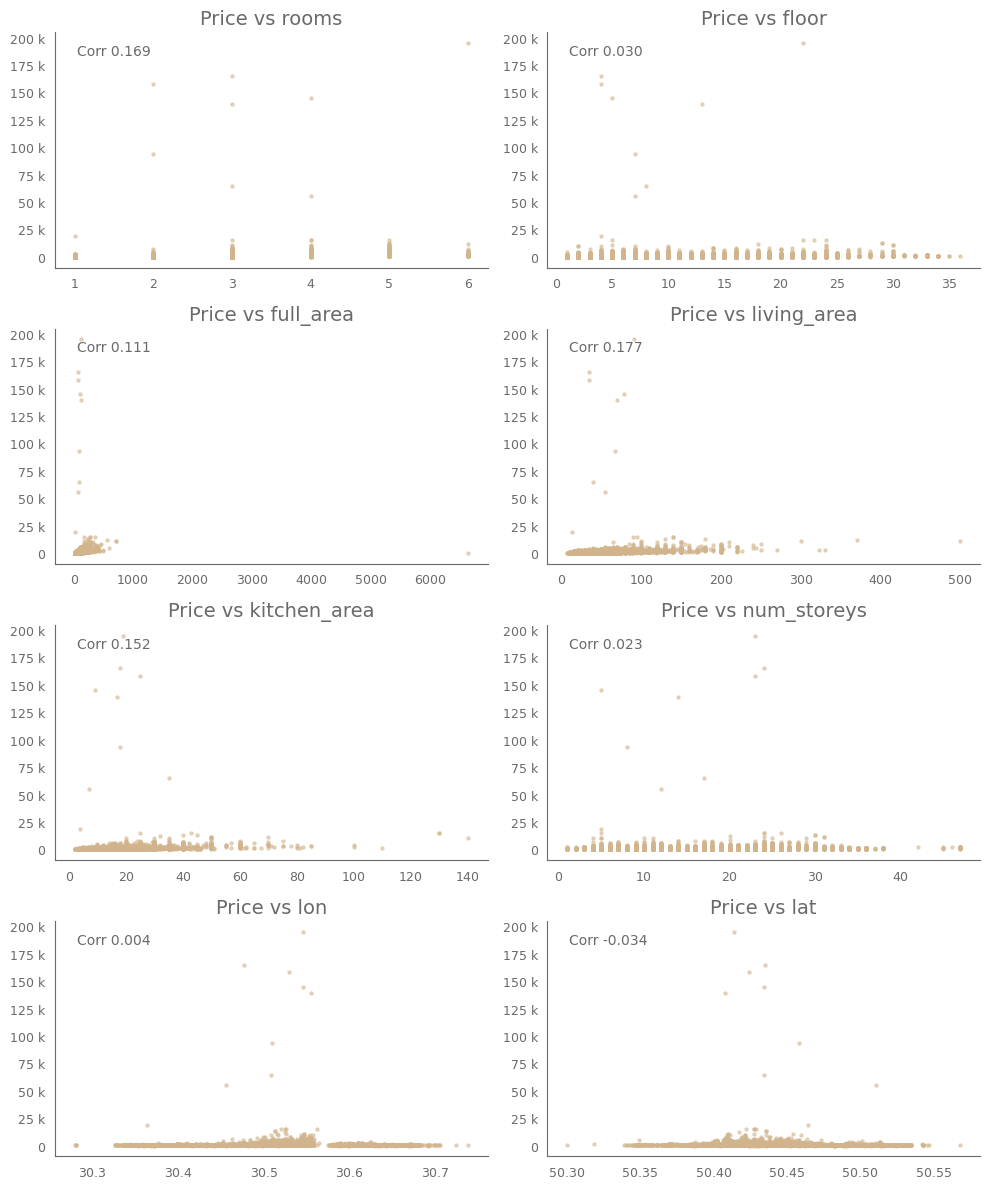

In [41]:
plot_numerical_vs_target(filtered_data,
                         numerical_cols[:-1],
                         target_col='price',
                         filter_iqr=False)

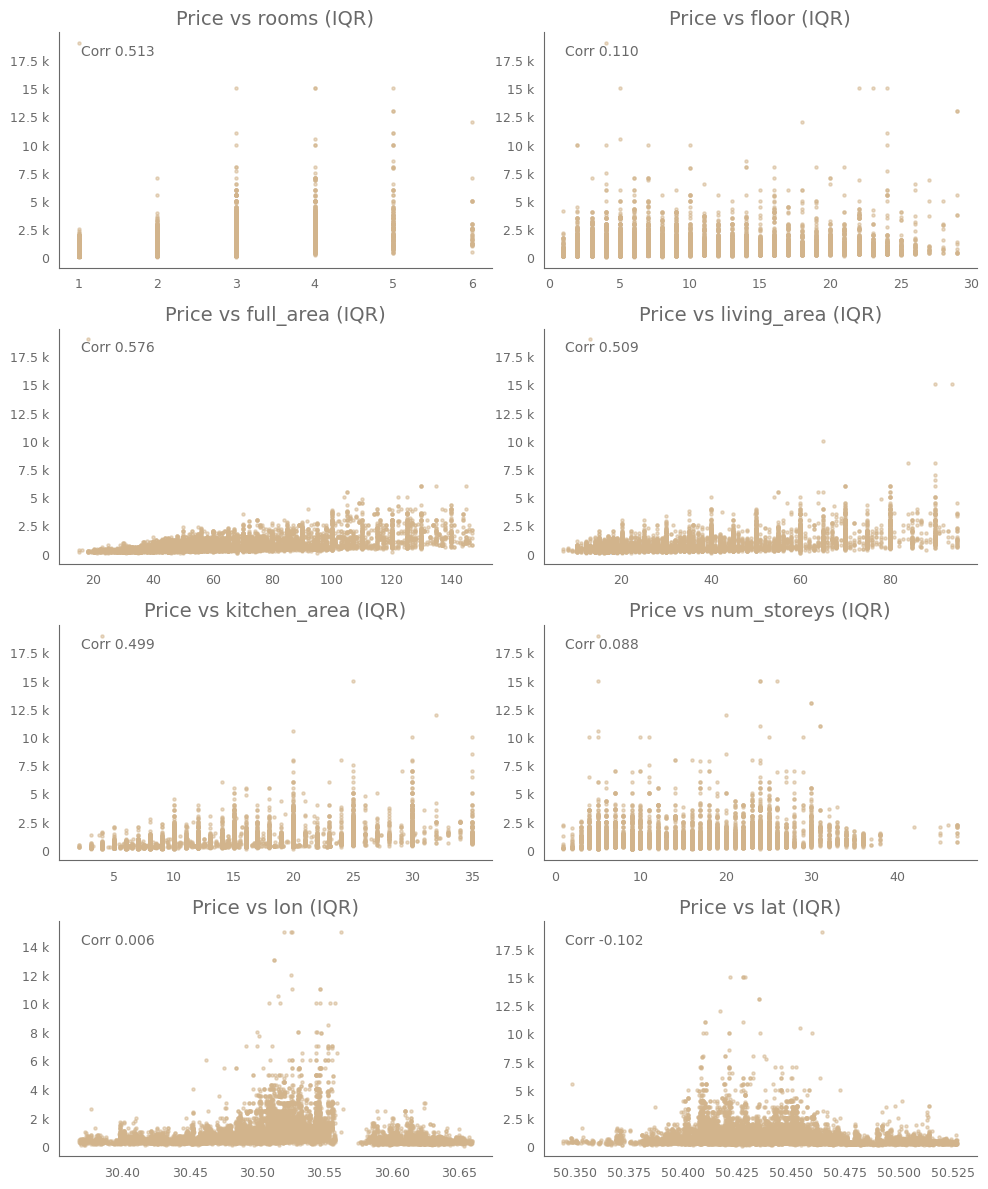

In [42]:
plot_numerical_vs_target(filtered_data_50, numerical_cols[:-1], target_col='price', filter_iqr=True)

Strongest correlation with Price after applying IQR filtering for numerical features:
- **Full Area (0.576):** The most reliable linear relationship. As full_area increases, price tends to increase.
- **Rooms (0.513)** and **Living Area (0.509)** also show moderately strong positive relationships. More rooms or more living space generally lead to higher rental prices.
- **Kitchen Area (0.499):** Also positively correlated, though less strongly. Larger kitchens generally accompany higher prices.

Weak or no correlation:
- **Floor (0.110)** and **Num Storeys (0.088)**: Little influence on price within IQR.
- **Longitude (0.006)** and **Latitude (-0.102)**: Almost no linear correlation, but they might still contain non-linear or cluster-based spatial patterns.

Other observations:
- **Room** distribution is discrete with most properties having 1–3 rooms.
- **Floor** and **Num Storeys**: Show some preference for mid-level floors, with visible spikes (e.g., 10th, 16th floor), but no strong price trend.
- **Kitchen and Living Areas**: Most properties cluster below 100 sq.m. for living area and 50 sq.m. for kitchen area, indicating typical apartment sizes.
- **Full Area**: Continuous distribution with a clear upward trend with price—likely the most important feature.

## Categorical feature analysis

In [30]:
data.select_dtypes(include='object').columns.tolist()

['address',
 'coordinates',
 'region',
 'subway',
 'footage',
 'features',
 'residential',
 'neighborhood',
 'description',
 'detail',
 'attributes',
 'district',
 'neighborhood_1',
 'neighborhood_2',
 'neighborhood_3',
 'neighborhood_4',
 'neighborhood_5']

In [31]:
black_cat_feats = ['address', 'coordinates', 'region', 'footage', 'features',
                   'neighborhood', 'description', 'detail', 'attributes']
categorical_cols = data.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in black_cat_feats]
print(f'Number of categorical features: {len(categorical_cols)}')
print(f"Categorical features: {categorical_cols}")

Number of categorical features: 8
Categorical features: ['subway', 'residential', 'district', 'neighborhood_1', 'neighborhood_2', 'neighborhood_3', 'neighborhood_4', 'neighborhood_5']



SUBWAY
Unique values: 52

Top 10 values:
subway
Звіринецька      684
Вокзальна        453
Либідська        449
Лук'янівська     445
Палац Україна    425
Золоті Ворота    343
Печерська        339
Позняки          337
Осокорки         315
Лівобережна      302
Name: count, dtype: int64

Average rent by subway:


,mean,median,count
subway,,,
Театральна,18403.97,925.0,68
Видубичі,2645.57,1300.0,147
Олімпійська,2183.08,1400.0,286
Звіринецька,2167.80,1500.0,684
Печерська,2089.34,1000.0,339
Золоті Ворота,1859.41,1500.0,343
Поштова площа,1825.92,1000.0,25
Контрактова площа,1714.64,999.0,193
Арсенальна,1599.91,1000.0,109



ANOVA F-statistic: 2.96, p-value: 1.12e-11


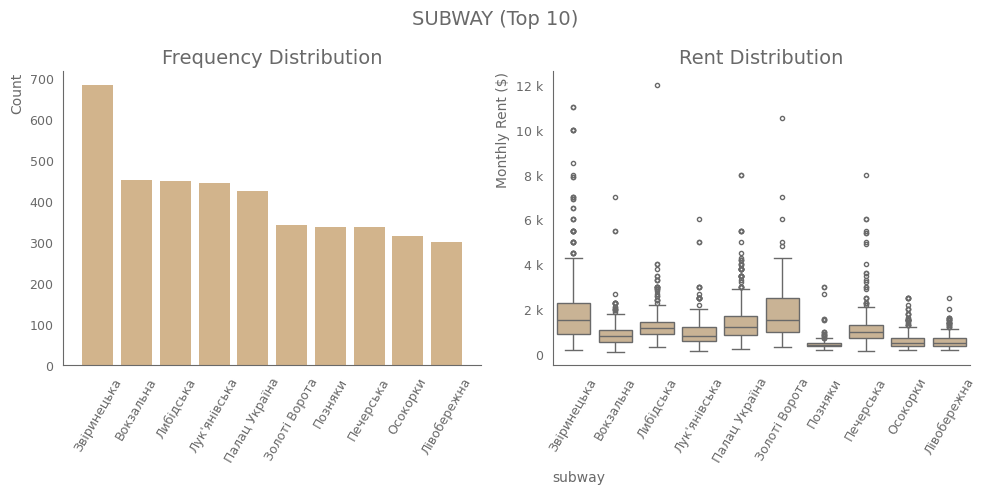


RESIDENTIAL
Unique values: 421

Top 10 values:
residential
ЖК Новопечерські Липки      317
ЖК Французький квартал 2    207
ЖК Нова Англія              120
ЖК Park Avenue VIP          107
ЖК Французький квартал       95
ЖК Зарічний                  94
ЖК Комфорт Таун              92
ЖК Central Park              90
ЖК Ярославів Град            84
ЖК ЖМ Патріотика             80
Name: count, dtype: int64

Average rent by residential:


,mean,median,count
residential,,,
ЖК Greenville на Печерську,19172.22,2000.0,9
ЖК Resident Concept House,14266.00,1600.0,5
"ЖК на Андріївський узвіз, 30-34в",10000.00,10000.0,1
ЖК Подол Град,9756.36,1300.0,11
ЖК Малахіт,8893.00,720.0,20
ЖК Тріумф,5530.56,1500.0,36
ЖК Pechersk Hills Residence,4750.00,4750.0,2
"ЖК на вул. Івана Франка, 11",4000.00,4000.0,1
ЖК Signature,4000.00,4000.0,1



ANOVA F-statistic: 1.03, p-value: 3.36e-01


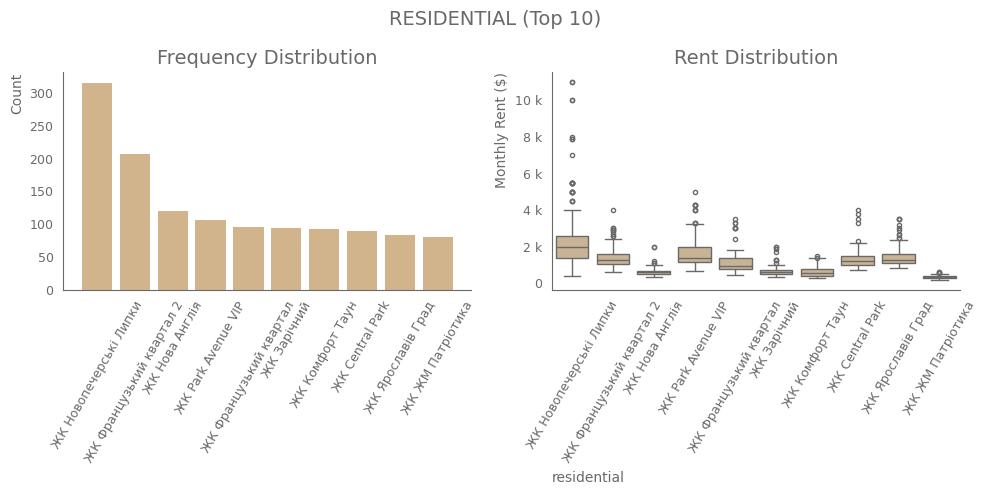


DISTRICT
Unique values: 10

Top 10 values:
district
Печерський        2579
Шевченківський    1949
Голосіївський     1507
Дарницький        1411
Солом'янський      922
Дніпровський       834
Подільський        699
Оболонський        643
Святошинський      530
Деснянський        362
Name: count, dtype: int64

Average rent by district:


,mean,median,count
district,,,
Печерський,1827.76,1200.0,2579
Шевченківський,1696.68,900.0,1949
Голосіївський,938.56,640.0,1507
Подільський,821.44,490.0,699
Солом'янський,720.81,455.0,922
Оболонський,712.00,480.0,643
Дарницький,505.69,410.0,1411
Дніпровський,477.22,390.0,834
Святошинський,453.95,370.0,530



ANOVA F-statistic: 3.18, p-value: 7.68e-04


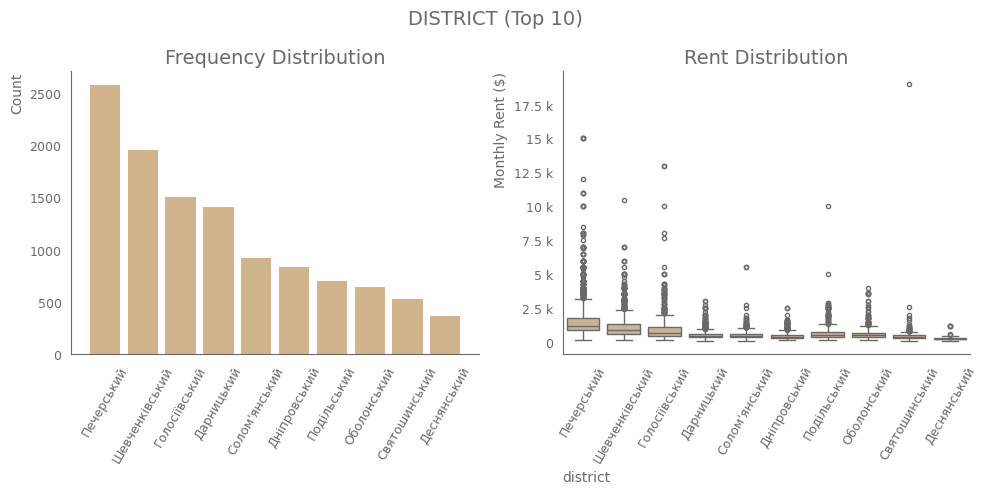


NEIGHBORHOOD_1
Unique values: 287

Top 10 values:
neighborhood_1
Новопечерські липки     387
ТЦ Ocean Plaza          289
Бусове поле             235
Осокорки                234
ТЦ River Mall           231
ТЦ "Інтервал-Плаза"     216
Солдатська слобідка     194
Володимирський ринок    183
КНУКіМ                  182
ТЦ Retroville           154
Name: count, dtype: int64

Average rent by neighborhood_1:


,mean,median,count
neighborhood_1,,,
Парк ім. Шевченка,32196.49,1040.0,37
Свято-Введенський монастир,6733.46,900.0,26
Пейзажна алея,6340.53,1500.0,19
Автозаводська,5397.27,390.0,11
Батьківщина-Мати,5050.00,2800.0,6
Національний ботанічний сад ім. М. М. Гришка,3434.81,3000.0,27
Андріївський Узвіз,2798.00,1975.0,10
Старий Київ,2453.52,2250.0,54
Новопечерські липки,2430.98,1700.0,387



ANOVA F-statistic: 1.03, p-value: 3.48e-01


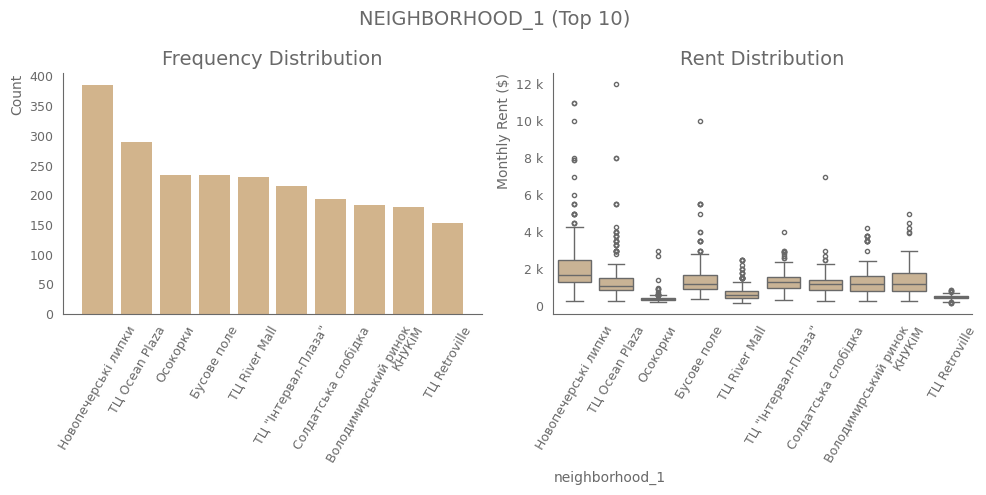


NEIGHBORHOOD_2
Unique values: 238

Top 10 values:
neighborhood_2
Новопечерські липки                      316
ТЦ Ocean Plaza                           264
Юрковиця                                 220
Оболонь                                  207
Охматдит                                 203
Ботанічний сад ім. акад. О. В. Фоміна    195
Бусове поле                              177
Афанасівський яр                         169
Старий Київ                              146
Стадіон Олімпійський                     140
Name: count, dtype: int64

Average rent by neighborhood_2:


,mean,median,count
neighborhood_2,,,
Бессарабка,16645.53,1210.0,76
Воздвиженка,13130.00,1600.0,8
Батьківщина-Мати,10000.00,10000.0,2
Пріорка,9568.33,385.0,6
Національний ботанічний сад ім. М. М. Гришка,3975.44,1500.0,66
Солом'янська площа,3090.80,1000.0,75
Звіринець,3036.87,2900.0,52
Печерськ,2417.92,1000.0,133
Пам'ятник засновникам Києва,2400.00,2400.0,2



ANOVA F-statistic: 0.49, p-value: 1.00e+00


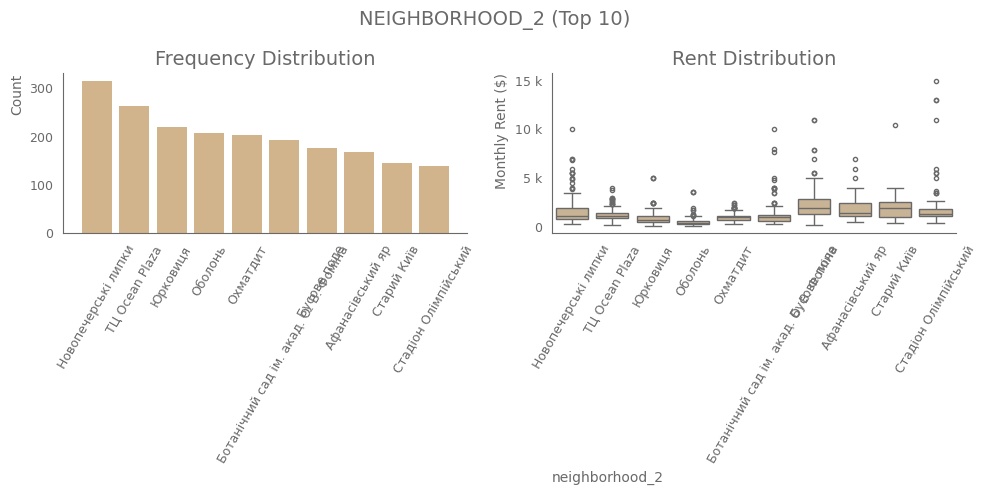


NEIGHBORHOOD_3
Unique values: 167

Top 10 values:
neighborhood_3
Чорна гора                               308
Юрковиця                                 252
Голосіїв                                 169
Бусове поле                              156
Кучмин яр                                122
Ботанічний сад ім. акад. О. В. Фоміна    112
Пологовий будинок № 1                    111
Проспект Соборності                      106
Бессарабка                                97
Стадіон Олімпійський                      95
Name: count, dtype: int64

Average rent by neighborhood_3:


,mean,median,count
neighborhood_3,,,
Вишгородський масив,27940.00,27940.0,2
Києво-Печерська лавра,12805.83,705.0,12
Ботанічний сад ім. акад. О. В. Фоміна,12348.55,2000.0,112
Пам'ятник засновникам Києва,6375.00,4750.0,4
Театр опери та балету,3500.00,3500.0,1
Батьківщина-Мати,3338.85,3000.0,46
Пейзажна алея,2225.69,2000.0,61
Стадіон Олімпійський,2046.16,1600.0,95
Чорна гора,2018.06,1600.0,308



ANOVA F-statistic: 0.31, p-value: 1.00e+00


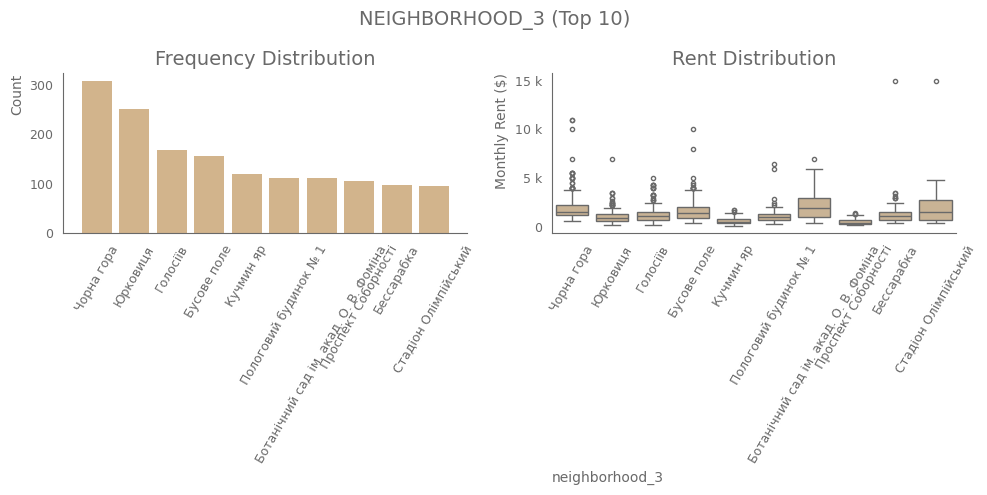


NEIGHBORHOOD_4
Unique values: 103

Top 10 values:
neighborhood_4
Черепанова гора                          125
Юрковиця                                  81
Печерськ                                  70
Куренівка                                 67
Ботанічний сад ім. акад. О. В. Фоміна     64
Бессарабка                                60
Офіс Президента                           59
Поділ                                     52
Осокорки                                  46
Афанасівський яр                          41
Name: count, dtype: int64

Average rent by neighborhood_4:


,mean,median,count
neighborhood_4,,,
Липки,2906.09,1300.0,23
Черепанова гора,1929.88,1500.0,125
Пейзажна алея,1912.22,1500.0,9
Офіс Президента,1681.53,1500.0,59
Арка Свободи,1585.00,1550.0,4
Афанасівський яр,1573.44,1300.0,41
Печерський ринок,1550.00,1550.0,1
Батьківщина-Мати,1500.00,1500.0,1
Ботанічний сад ім. акад. О. В. Фоміна,1499.34,1100.0,64



ANOVA F-statistic: 3.95, p-value: 8.52e-31


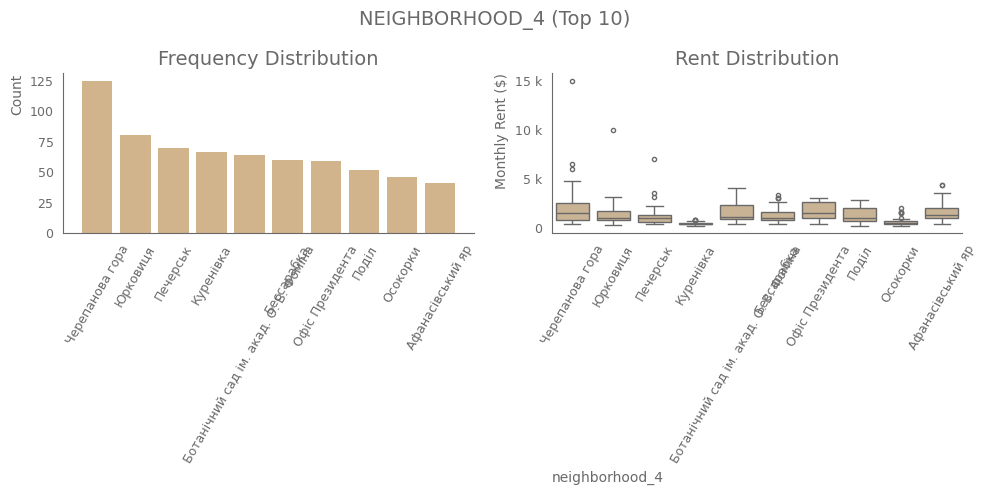


NEIGHBORHOOD_5
Unique values: 53

Top 10 values:
neighborhood_5
Липки                                    58
Печерськ                                 57
Юрковиця                                 56
Куренівка                                44
Ботанічний сад ім. акад. О. В. Фоміна    37
Володимирська Гірка                      19
Голосіїв                                 19
Черепанова гора                          12
Поділ                                    11
Пологовий будинок № 1                    10
Name: count, dtype: int64

Average rent by neighborhood_5:


,mean,median,count
neighborhood_5,,,
Новопечерські липки,8350.00,8600.0,4
Бессарабка,3300.00,3300.0,1
ТЦ Гулівер,2555.00,2555.0,2
Нижні сади,2000.00,2000.0,1
Липки,1711.72,1500.0,58
Стадіон «Динамо» Лобановського,1500.00,1500.0,1
Юрковиця,1416.25,1150.0,56
Охматдит,1410.00,1410.0,1
Володимирська Гірка,1362.53,1000.0,19



ANOVA F-statistic: 6.40, p-value: 1.01e-28


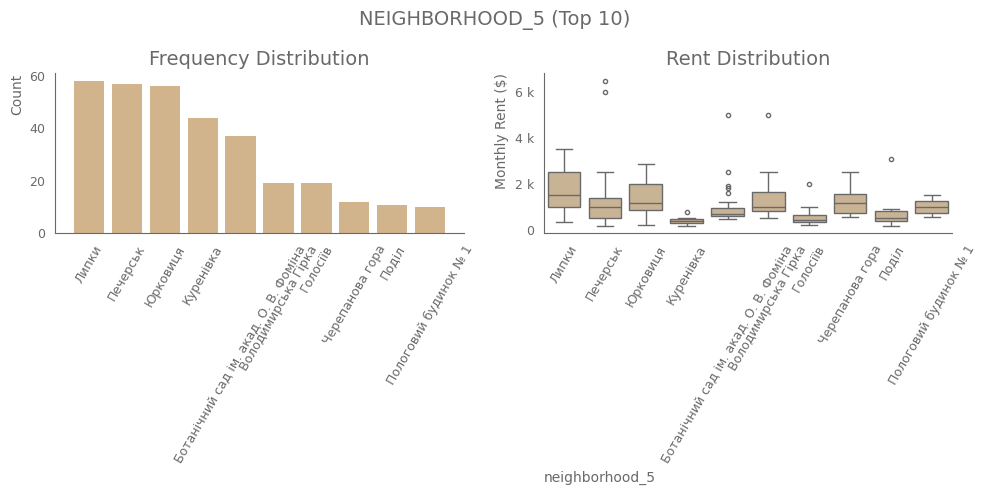

In [32]:
for col in categorical_cols:
    analyze_categorical_feature(data, col)
    plot_categorical_distribution(filtered_data_50, col)

1. **Subway Stations**
- Median rents at most stations hover around ₴1,000–1,500, but some (e.g., Театральна) have higher mean values, likely due to luxury outliers.
- Statistical Test (ANOVA):
    - F = 2.96, p-value = 1.12e-11
    - **Statistically significant** differences in rent prices across subway stations.
- Conclusion: Subway location impacts rent, though this may be partly driven by skewed luxury listings.

2. **District Analysis**
- Median < Mean in most districts, so we could suggest a positively skewed distribution due to high-end outliers.
- Statistical Test (ANOVA):
    - F = 3.18, p-value = 7.68e-04
    - **Statistically significant** difference in rental prices across districts.
- Conclusion: District is a strong feature for rental price modeling.

3. **Residential Complexes (ЖК)**
- 421 unique residential complexes identified.
- Top 10 by mean rent show large mean–median gaps, suggesting luxury outliers skew the mean.
- Statistical Test (ANOVA):
    - F = 1.03, p-value = 0.336
    - **Not statistically significant**.
- Conclusion: Rental prices do not differ significantly across residential complexes. Likely due to:
    - High variance within buildings.
    - Low sample sizes.
    - Outliers (e.g., penthouses in standard buildings).

4.  **Neighborhoods**
- Statistical Test (ANOVA):
    - For Neighborhood 1–3 **No statistically significant** difference in rental prices across neighborhoods
    - For Neighborhood 4–5 **statistically significant** difference in rental prices across neighborhoods, but sample sizes become small and sparse.
- Even though some neighborhoods show high mean rents, variability makes the differences statistically meaningless.
- Many neighborhoods include a wide mix of property types (e.g., standard flats vs. luxury apartments), diluting statistical distinctions.


**Feature Engineering Recommendations**:
- Use district and subway station as primary categorical features.
- Use residential complex only with sufficient data:
    - Keep top 10–20 complexes as categories.
    - Group others as “Other” or “Low-frequency” to reduce sparsity and overfitting risk.
- Limit to Top 10–20 categories of neighborhoods by frequency to reduce sparsity.

## Geographical analysis

In [33]:
geo_cols = [col for col in data.columns if any(geo_term in col.lower()
            for geo_term in ['lat', 'lon', 'neighborhood_', 'district'])]

print(f"Number of geographical columns: {len(geo_cols)}")
print(f"Geographical columns found: {geo_cols}")

Number of geographical columns: 8
Geographical columns found: ['district', 'lon', 'lat', 'neighborhood_1', 'neighborhood_2', 'neighborhood_3', 'neighborhood_4', 'neighborhood_5']


### Districts

In [34]:
district_stats = data.groupby('district')['price'].agg([
    'count', 'mean', 'median', 'std'
]).round(2).sort_values('mean', ascending=False)
district_stats

,count,mean,median,std
district,,,,
Печерський,2579,1827.76,1200.0,6405.17
Шевченківський,1949,1696.68,900.0,26038.44
Голосіївський,1507,938.56,640.0,1866.95
Подільський,699,821.44,490.0,3566.91
Солом'янський,922,720.81,455.0,5428.57
Оболонський,643,712.00,480.0,2219.40
Дарницький,1411,505.69,410.0,318.56
Дніпровський,834,477.22,390.0,292.75
Святошинський,530,453.95,370.0,839.04


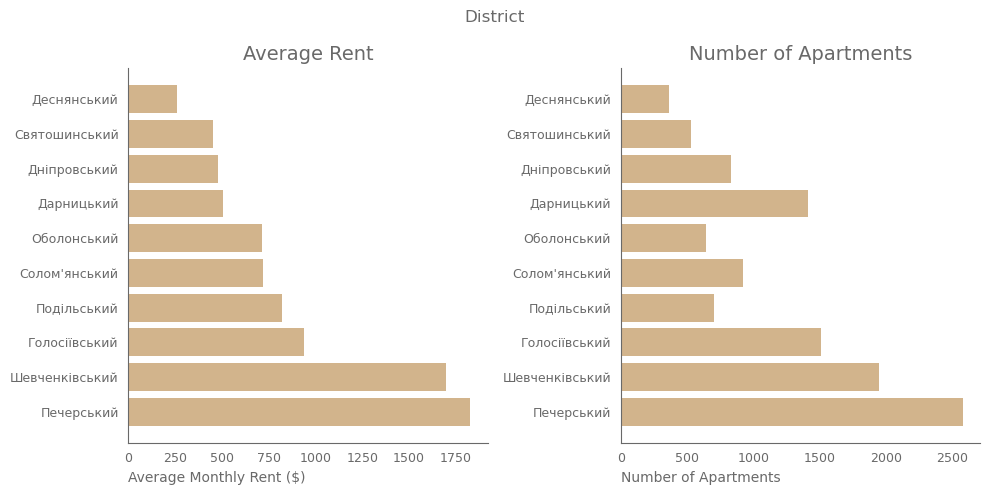

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
plt.suptitle("District")
# Average rent by district
ax1.barh(range(len(district_stats)), district_stats['mean'], color=COLOR_PLOT)
ax1.set_title('Average Rent')
ax1.set_xlabel('Average Monthly Rent ($)')
ax1.set_yticks(range(len(district_stats)))
ax1.set_yticklabels(district_stats.index)

ax2.barh(range(len(district_stats)), district_stats['count'], color=COLOR_PLOT)
ax2.set_title('Number of Apartments')
ax2.set_xlabel('Number of Apartments')
ax2.set_yticks(range(len(district_stats)))
ax2.set_yticklabels(district_stats.index)

plt.tight_layout()
plt.show()

- Most Expensive Districts:
    - Печерський and Шевченківський lead the market with mean rents above ₴1,600, suggesting premium housing, luxury apartments, or business-class buildings.
    - However, the very high standard deviation in Шевченківський (₴26,038!) indicates significant outliers—perhaps short-term luxury rentals or misentries.
- Mid-Tier Districts:
    - Голосіївський and Подільський offer more affordable alternatives in central or green areas.
    - Median rents (₴640–₴490) reflect more realistic typical pricing than the mean.
- Affordable Districts:
    - Дарницький, Дніпровський, Святошинський, and especially Деснянський are the most budget-friendly.
    - Деснянський shows both lowest mean and lowest variability, indicating stable, low-cost housing options.

### Neighborhoods

In [36]:
neighborhood_cols = [col for col in geo_cols if "neighborhood_" in col]


NEIGHBORHOOD_1
Top neighborhoods (min 10 listings):


,count,mean,median,std
neighborhood_1,,,,
Парк ім. Шевченка,37,32196.49,1040.0,188871.36
Свято-Введенський монастир,26,6733.46,900.0,28236.40
Пейзажна алея,19,6340.53,1500.0,21121.85
Автозаводська,11,5397.27,390.0,16617.27
Національний ботанічний сад ім. М. М. Гришка,27,3434.81,3000.0,1694.38
Андріївський Узвіз,10,2798.00,1975.0,2575.16
Старий Київ,54,2453.52,2250.0,1449.49
Новопечерські липки,387,2430.98,1700.0,7111.98
Печерський міст,69,2421.26,2020.0,2070.83



NEIGHBORHOOD_2
Top neighborhoods (min 10 listings):


,count,mean,median,std
neighborhood_2,,,,
Бессарабка,76,16645.53,1210.0,131741.69
Національний ботанічний сад ім. М. М. Гришка,66,3975.44,1500.0,17017.26
Солом'янська площа,75,3090.80,1000.0,18951.90
Звіринець,52,3036.87,2900.0,2034.36
Печерськ,133,2417.92,1000.0,12556.29
Андріївський Узвіз,12,2387.50,2500.0,598.15
Бусове поле,177,2328.10,2000.0,1609.48
Софіївська площа,13,2186.00,1450.0,1626.39
Новопечерські липки,316,2166.77,1200.0,10951.64



NEIGHBORHOOD_3
Top neighborhoods (min 10 listings):


,count,mean,median,std
neighborhood_3,,,,
Києво-Печерська лавра,12,12805.83,705.0,41633.21
Ботанічний сад ім. акад. О. В. Фоміна,112,12348.55,2000.0,108473.06
Батьківщина-Мати,46,3338.85,3000.0,1971.53
Пейзажна алея,61,2225.69,2000.0,1530.26
Стадіон Олімпійський,95,2046.16,1600.0,1826.72
Чорна гора,308,2018.06,1600.0,1382.17
Кучмин яр,122,1988.61,570.0,14884.12
ЦУМ,30,1942.33,2000.0,997.82
Бусове поле,156,1773.75,1420.0,1266.21



NEIGHBORHOOD_4
Top neighborhoods (min 10 listings):


,count,mean,median,std
neighborhood_4,,,,
Липки,23,2906.09,1300.0,3953.09
Черепанова гора,125,1929.88,1500.0,1729.07
Офіс Президента,59,1681.53,1500.0,856.48
Афанасівський яр,41,1573.44,1300.0,954.86
Ботанічний сад ім. акад. О. В. Фоміна,64,1499.34,1100.0,928.10
Стадіон Олімпійський,11,1429.09,1450.0,527.64
Зоопарк,25,1367.12,1200.0,735.42
Поділ,52,1363.42,994.5,823.06
Старий Київ,21,1344.67,950.0,1000.31



NEIGHBORHOOD_5
Top neighborhoods (min 10 listings):


,count,mean,median,std
neighborhood_5,,,,
Липки,58,1711.72,1500.0,848.14
Юрковиця,56,1416.25,1150.0,762.06
Володимирська Гірка,19,1362.53,1000.0,1048.96
Черепанова гора,12,1291.67,1150.0,687.60
Печерськ,57,1170.18,1000.0,1092.71
Пологовий будинок № 1,10,1012.00,1000.0,329.30
Ботанічний сад ім. акад. О. В. Фоміна,37,962.97,700.0,815.39
Поділ,11,770.00,500.0,806.41
Голосіїв,19,550.00,410.0,403.44


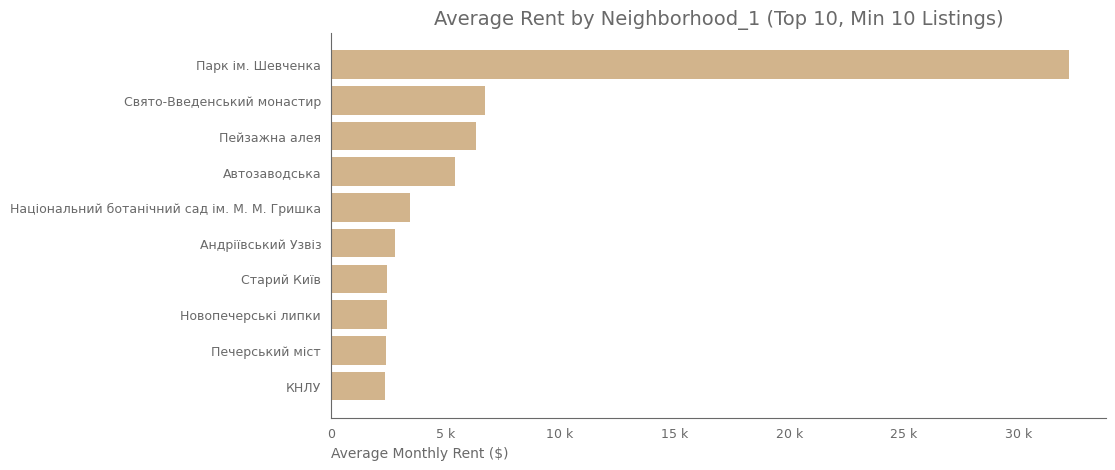

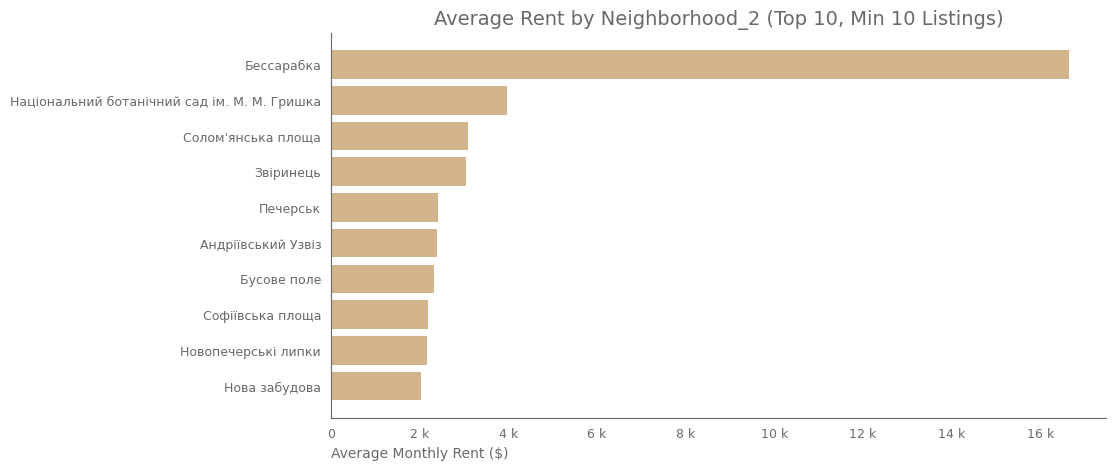

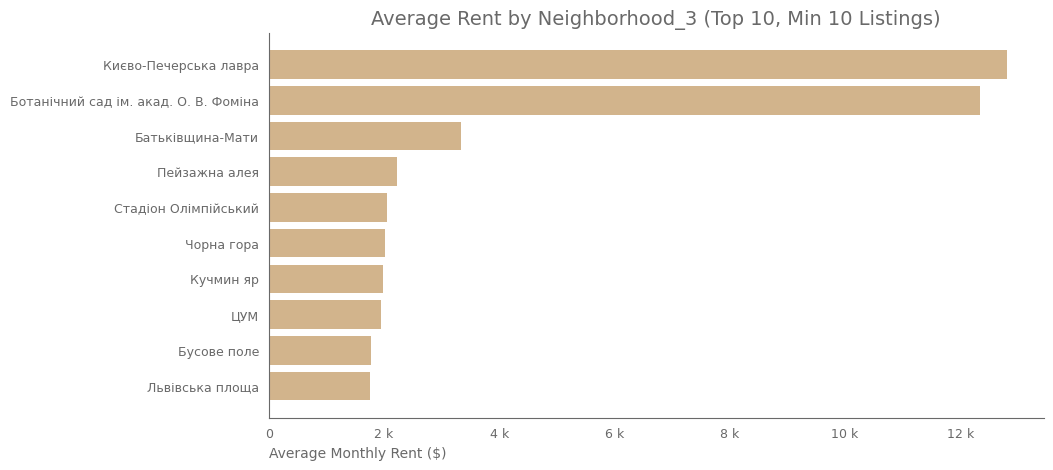

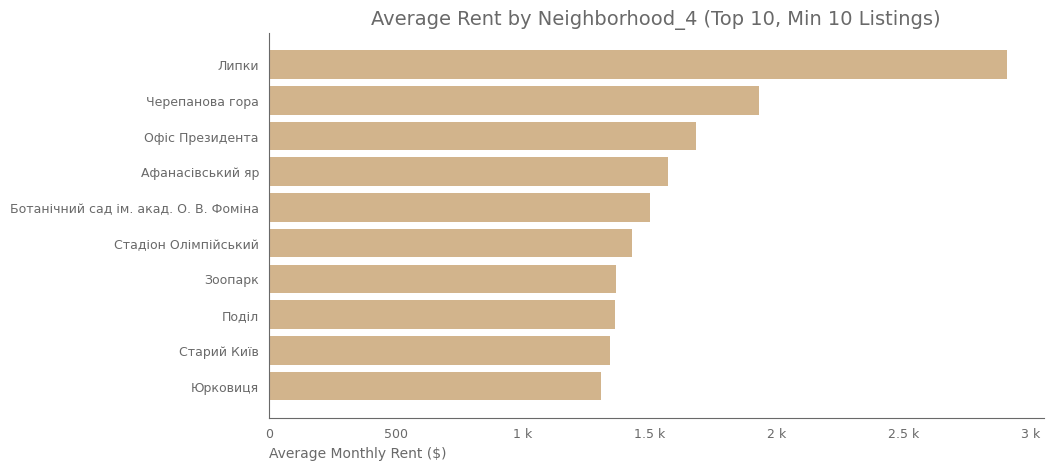

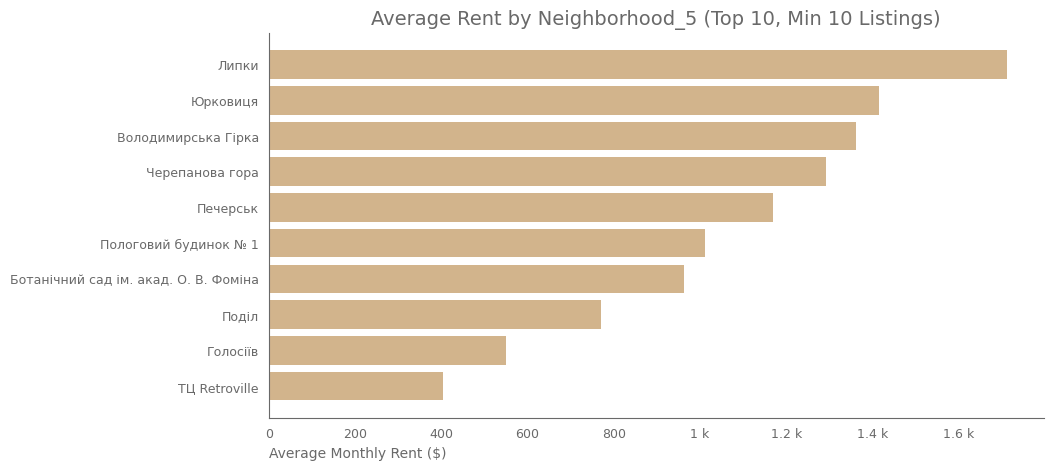

In [37]:
for col in neighborhood_cols:
    analyze_neighborhoods(data, col)

- Many entries have extreme outliers (especially Парк ім. Шевченка, Бессарабка, Ботанічний сад ім. акад. О. В. Фоміна). 
- The median values often are much lower than the mean, indicating skewed distributions due to luxury listings.
- Wide ranges, high standard deviations means are inflated by outliers.
- Level 3-5 still sees large price spreads, but the median stabilizes.

### Latitude and Longitude

In [38]:
print(f"Latitude range: {data['lat'].min():.4f} to {data['lat'].max():.4f}")
print(f"Longitude range: {data['lon'].min():.4f} to {data['lon'].max():.4f}")

Latitude range: 50.3003 to 50.5680
Longitude range: 30.2792 to 30.7381


In [39]:
fig = px.scatter_mapbox(
    filtered_data_50,
    lat='lat',
    lon='lon',
    color='price',
    hover_data=['rooms', 'living_area'],
    size='price',
    color_continuous_scale='aggrnyl',
    zoom=10,
    mapbox_style='open-street-map',
    title = "Apartment Rent Distribution Map",
    height=600
)

iplot(fig)

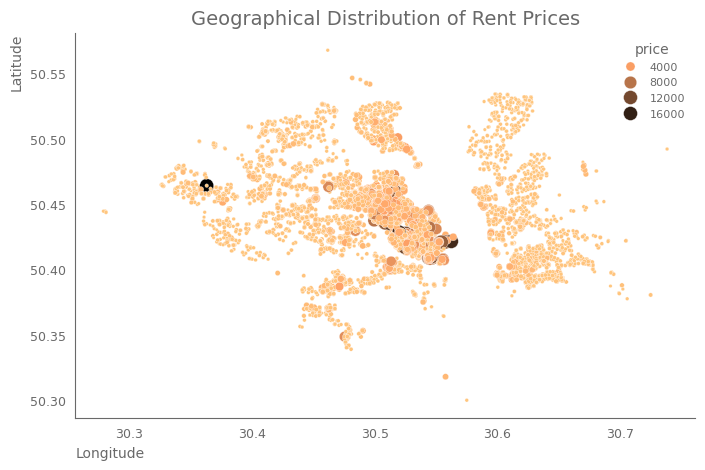

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='lon', y='lat', data=filtered_data_50, hue='price',
                size='price', sizes=(5, 100), size_norm=(0, 10000),
                palette='copper_r')
plt.title("Geographical Distribution of Rent Prices")
plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.show()

- Rental prices in Kyiv are highly location-dependent, with city center and commercial areas demanding higher rents.
- The highest rent prices are densely concentrated in the central districts (Печерський, Шевченківський). 
- Peripheral or outlying districts such as: Деснянський, Святошинський, Дарницький, show much lower rental prices and fewer listings.
- Areas near major shopping centers (e.g., Ocean Plaza, River Mall) and metro lines also show higher price clusters, likely due to accessibility and infrastructure.
- Visualization confirms analytical results: Pecherskyi and Shevchenkivskyi districts dominate in terms of both listing density and price.